In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\tanay\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\9325B14D33E8D654C1151D686982F8DC4DF31304\transfers\2026-31\HOD\HOD\Data Cleaning datasets\diabetes_dirty_dataset.csv")
df

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,P0121,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,P0768,7,NaN,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,NaN,3.0,0
1011,P0746,2,131,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0
1012,P0071,4,144,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1
1013,P0608,0,79,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0


In [3]:
df.isnull().sum()

PatientID                    0
Pregnancies                  0
Glucose                     80
BloodPressure                0
SkinThickness               80
Insulin                     78
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                      0
dtype: int64

In [4]:
nums = ["Glucose","SkinThickness","Insulin","VitaminD","ExerciseHrsPerWeek","Outcome"]
for i in nums:
    df[i] = pd.to_numeric(df[i],errors="coerce")

In [5]:
import matplotlib.pyplot as plt
for i in nums:
    df[i] = df[i].fillna(df[i].median())

In [6]:
df.isnull().sum()

PatientID                   0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Cholesterol                 0
SodiumLevel                 0
HeartRate                   0
VitaminD                    0
ExerciseHrsPerWeek          0
Outcome                     0
dtype: int64

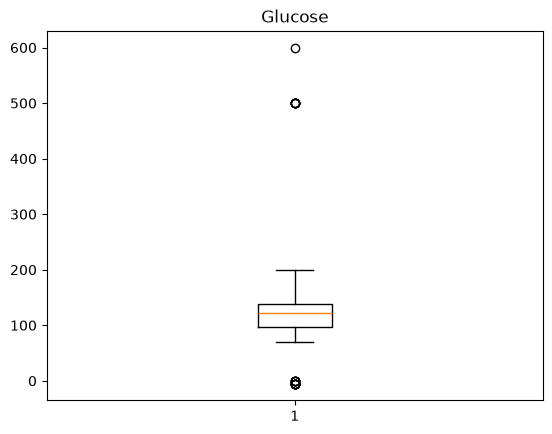

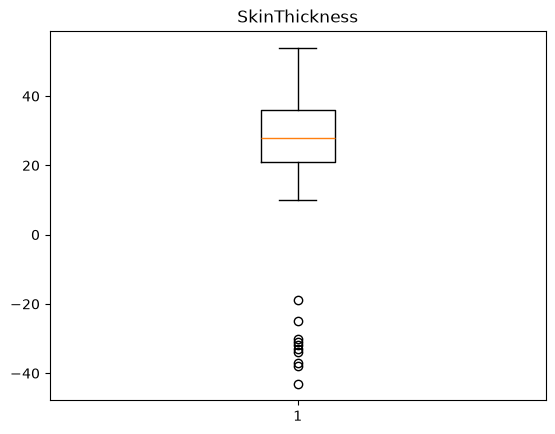

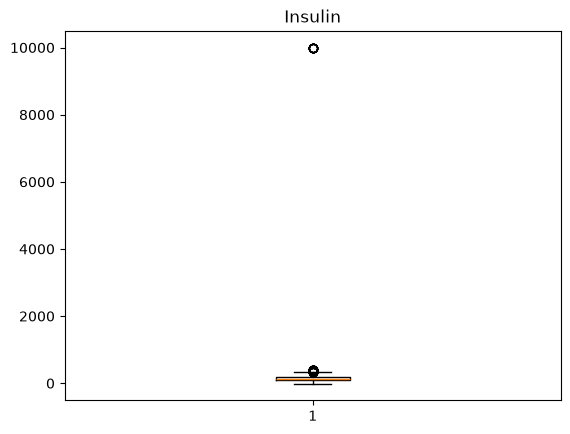

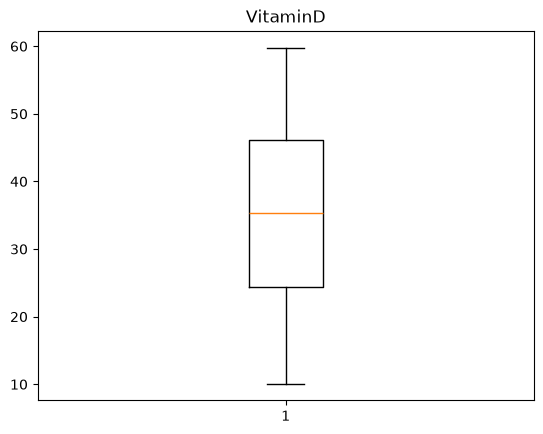

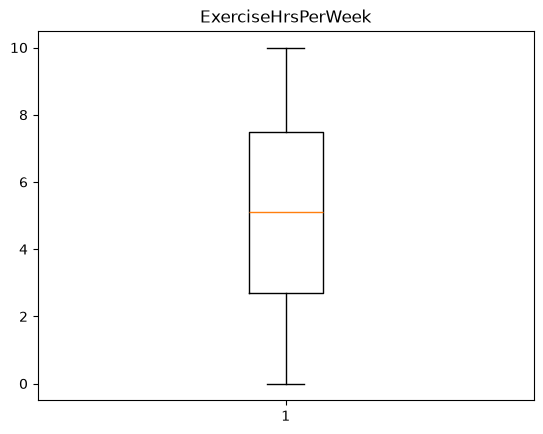

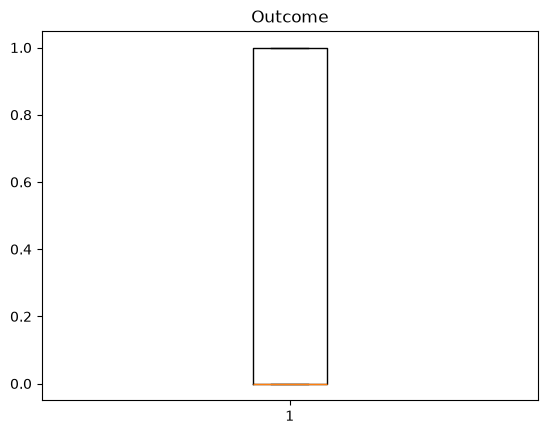

In [7]:

for i in nums:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

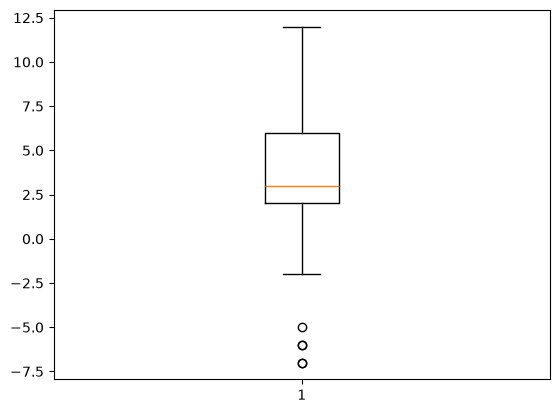

In [8]:
plt.boxplot(df["Pregnancies"])
plt.show()

In [9]:
n = ["Glucose","SkinThickness","Insulin","VitaminD","ExerciseHrsPerWeek","Pregnancies"]
for i in n:
    Q3 = df[i].quantile(0.75)
    Q1 = df[i].quantile(0.25)
    IQR = Q3-Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    median = df[i].median()
    df.loc[(df[i]<lower)| (df[i]>upper),i] = median
    df.loc[(df[i]<0),i] = median


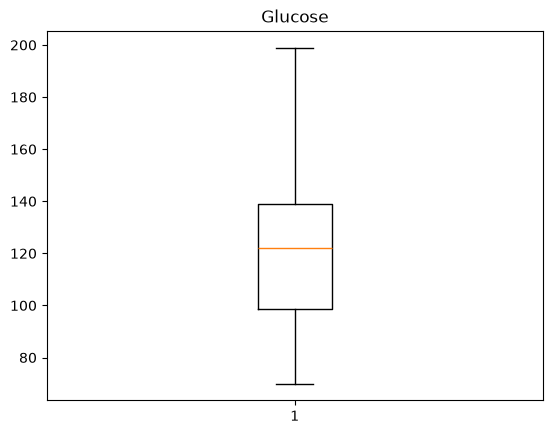

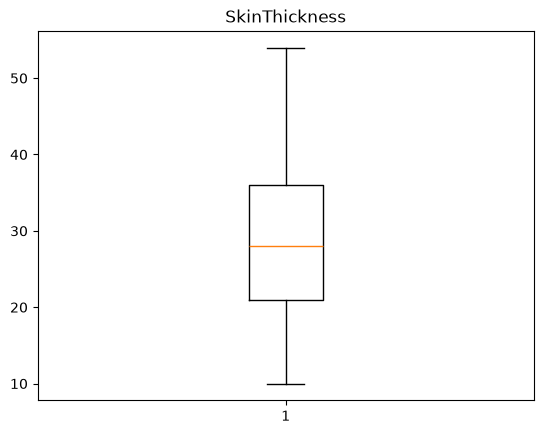

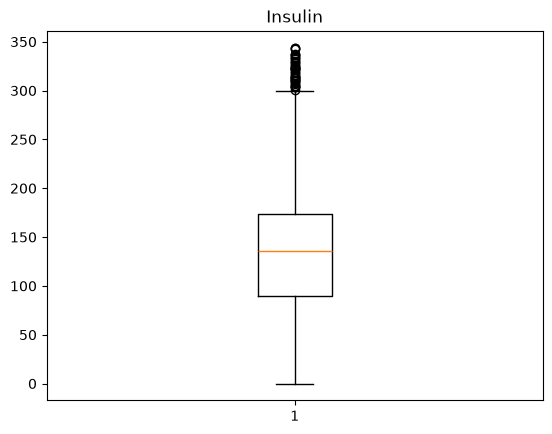

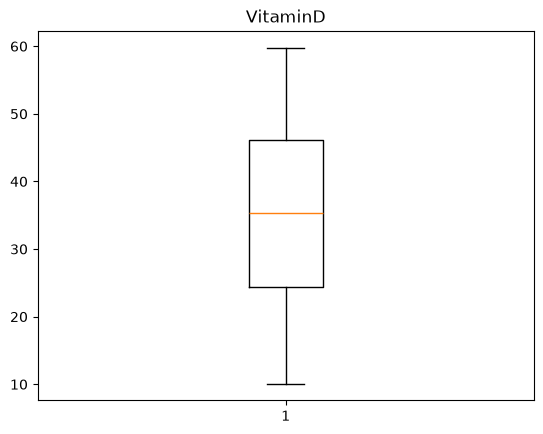

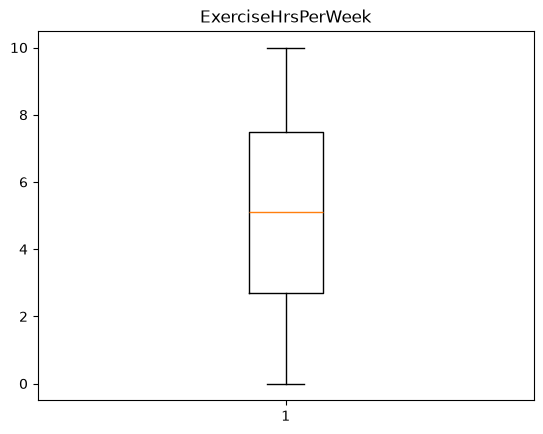

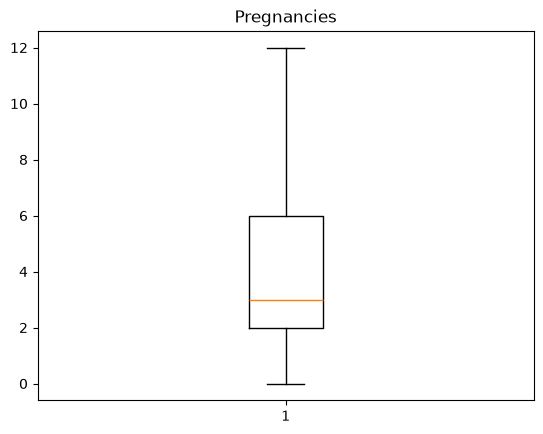

In [10]:
for i in n:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [11]:
from sklearn.model_selection import train_test_split
df = df.drop("PatientID",axis =1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,2,120.0,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0.0
1,8,121.0,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1.0
2,12,177.0,100,53.0,136.0,42.8,2.195,37.0,218,141.3,85,46.9,5.1,1.0
3,2,115.0,0,28.0,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0.0
4,2,129.0,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,7,122.0,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,35.3,3.0,0.0
1011,2,131.0,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0.0
1012,4,144.0,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1.0
1013,0,79.0,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0.0


In [13]:
df["Outcome"].replace({
    "False":0,
    "True":1,
    "FALSE": 0,
    "TRUE":1,
    "Yes":1,
    "No":0
    
})

0       0.0
1       1.0
2       1.0
3       0.0
4       0.0
       ... 
1010    0.0
1011    0.0
1012    1.0
1013    0.0
1014    0.0
Name: Outcome, Length: 1015, dtype: float64

In [16]:
from sklearn.model_selection import train_test_split
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,2,120.0,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0.0
1,8,121.0,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1.0
2,12,177.0,100,53.0,136.0,42.8,2.195,37.0,218,141.3,85,46.9,5.1,1.0
3,2,115.0,0,28.0,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0.0
4,2,129.0,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,7,122.0,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,35.3,3.0,0.0
1011,2,131.0,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0.0
1012,4,144.0,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1.0
1013,0,79.0,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0.0


In [17]:
x = df.iloc[:,0:13]
x.shape

(1015, 13)

In [20]:
y = df.iloc[:,-1]
y.shape

(1015,)

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,random_state = 42,test_size=0.2)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
lr = LogisticRegression()
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

In [32]:
y_pred

array([1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0.,
       0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1.,
       1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1.,
       0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1.])

In [33]:
result = pd.concat([pd.Series(y_pred),y_test.reset_index(drop=True)],axis=1)
result

,0,Outcome
0,1.0,1.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
198,0.0,0.0
199,0.0,0.0
200,0.0,0.0
201,0.0,0.0


In [36]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score

In [40]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
y_prob = lr.predict_proba(x_test)[:,1]
print("ROC AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9507389162561576
Precision: 0.8939393939393939
Recall   : 0.9516129032258065
F1 Score : 0.921875
[[134   7]
 [  3  59]]
ROC AUC : 0.9926790208190346
